In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib
import warnings

warnings.filterwarnings('ignore')

# 🧠 Understand The Dataset

In [5]:
df = pd.read_csv(r'/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [6]:
pd.set_option('display.max_columns',None)

In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.shape

(7043, 21)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
# Droping CustomerID column as this is not require for our modeling
df.drop(columns =['customerID'], inplace=True)

In [13]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [14]:
# printing the unique value of all columns

numerical_features = ['tenure','TotalCharges','MonthlyCharges']

for col in df.columns :
    if col not in numerical_features:
        print(col ,':', df[col].unique())
        print('-*'*50)

gender : ['Female' 'Male']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
SeniorCitizen : [0 1]
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Partner : ['Yes' 'No']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Dependents : ['No' 'Yes']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
PhoneService : ['No' 'Yes']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
MultipleLines : ['No phone service' 'No' 'Yes']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
InternetService : ['DSL' 'Fiber optic' 'No']
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
OnlineSecurity : ['No' 'Yes' 'No internet service']
-*-*-*-*-*-*-*-*-*-*-*

In [15]:
df['TotalCharges'].dtypes

dtype('O')

In [16]:
df[df['TotalCharges'] == ' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [17]:
len(df[df['TotalCharges'] == ' '])

11

In [18]:
df['TotalCharges'] = df['TotalCharges'].replace({' ':"0"})

df['TotalCharges'] = df['TotalCharges'].astype(float)

df['TotalCharges'].dtypes

dtype('float64')

In [19]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

**Insights :**

1. CustomerID removed as it is not required for modeling.
2. There are no missing values in the dataset.
3. Some of missing values in TotalCharges were replaced with 0.
4. The dataset is imbalanced.

# Exploratory Data Analysis (EDA)

In [20]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [21]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


**Let's understand the distribution of **Numerical Features****

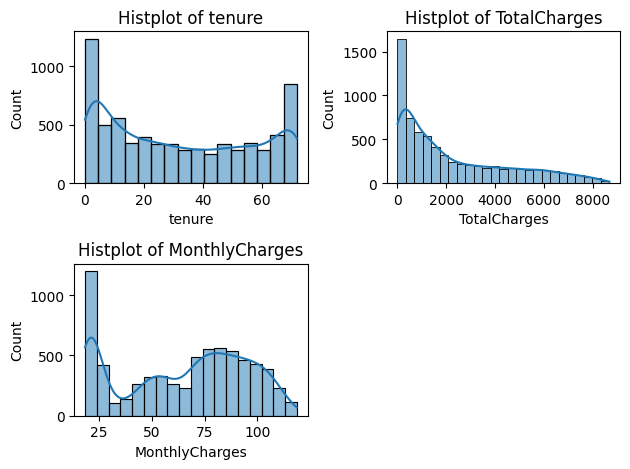

In [22]:
numeric_features = ['tenure','TotalCharges','MonthlyCharges']

for i, col in enumerate(numeric_features):
    plt.subplot(2, 2, 1+i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histplot of {col}')
    
plt.tight_layout()
plt.show()

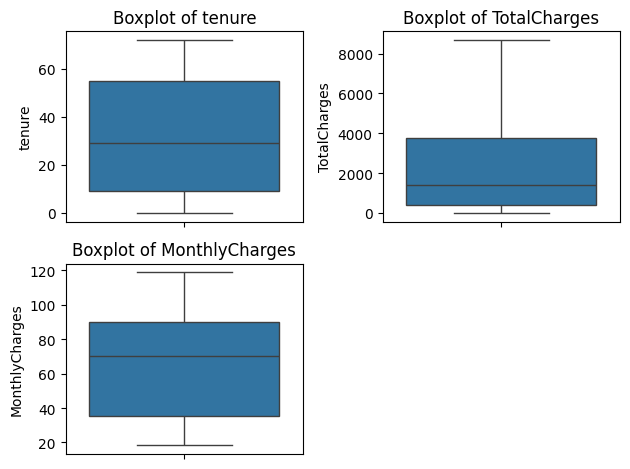

In [23]:
numeric_features = ['tenure','TotalCharges','MonthlyCharges']

for i, col in enumerate(numeric_features):
    plt.subplot(2, 2, 1+i)
    sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    
plt.tight_layout()
plt.show()

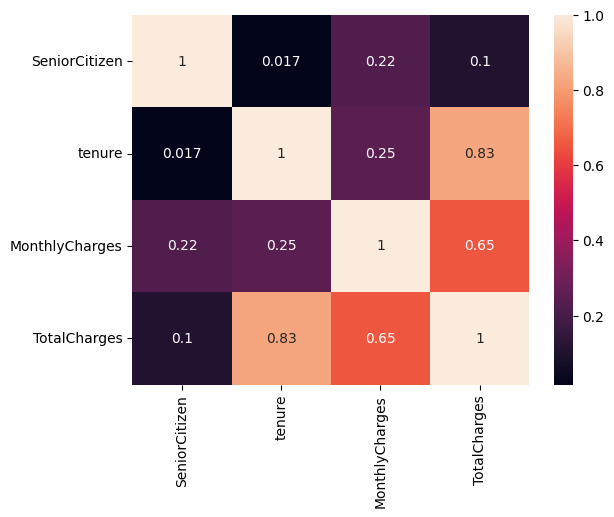

In [24]:
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True)
plt.show()

**Now let's understand the distribution of Categorical Features**

In [25]:
categorical_col = df.select_dtypes(include='object').columns.to_list()

categorical_col = categorical_col + ['SeniorCitizen']
categorical_col

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

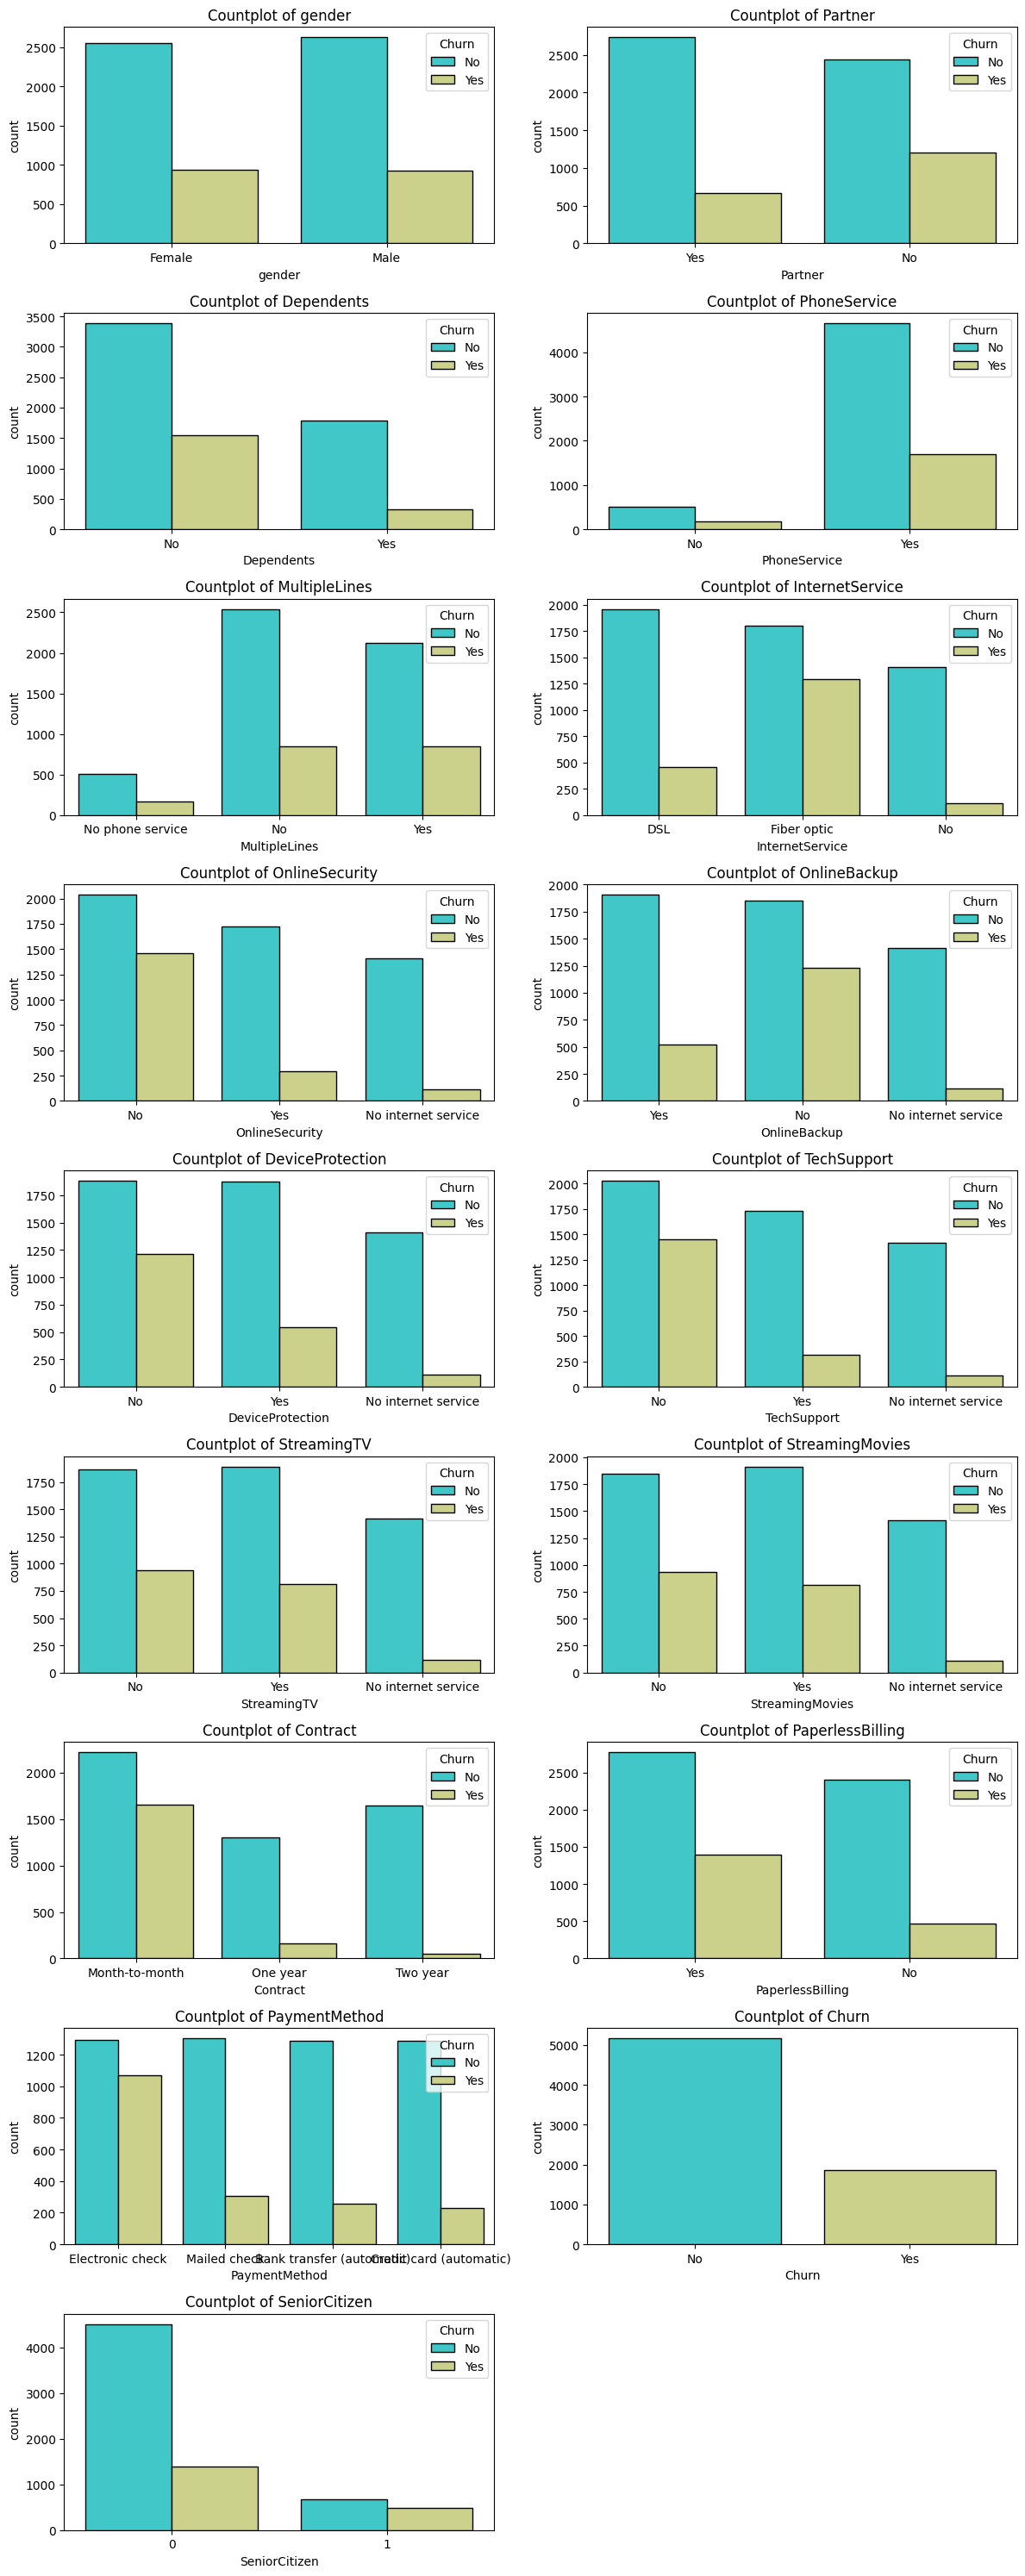

In [26]:
plt.figure(figsize=(12,30))

for i, col in enumerate(categorical_col):
    plt.subplot(9, 2, 1+i)
    
    sns.countplot(
        data= df,
        x= col,
        hue='Churn',
        palette='rainbow',
        edgecolor='black'
    )
    plt.title(f'Countplot of {col}')
    
plt.tight_layout()
plt.show()

# Data Preprocessing

**Now we are going to encode our data with the help of *One-Hot-Encoder* and *Label-Encoder*. Then we gonna witness that which Encoder is providing more accuracy**

1. **Label-Encoder**

In [27]:
object_col = df.select_dtypes(include='object').columns 
dataset = df.copy()

encoder_le = LabelEncoder()

for col in object_col:
    dataset[col] = encoder_le.fit_transform(dataset[col])

**2. One-Hot-Encoder**

In [28]:
object_col_2 = df.select_dtypes(include='object').columns 

encoder = OneHotEncoder(
    sparse_output=False,
    drop='first',
    handle_unknown='ignore'
)

encoded = encoder.fit_transform(df[object_col_2])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(object_col_2)
)

df = pd.concat(
    [df.drop(columns=object_col_2), encoded_df],
    axis=1
)

# **Train and Test split**

**1. Label-Encoder**

In [29]:
X = dataset.drop('Churn', axis = 1)
y = dataset['Churn']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

**2. One-Hot-Encoder**

In [31]:
x = df.drop('Churn_Yes', axis = 1)
y = df['Churn_Yes']

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [33]:
dataset['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

# SMOTE

**We can witness that our dataset is imbalance. Now we have to fix it with the help SMOTE**


**1. Label-Encoder**

In [34]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [35]:
print(y_train_smote.value_counts())

Churn_Yes
0.0    4138
1.0    4138
Name: count, dtype: int64


**2. One-Hot-Encoder**

In [36]:
smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

# Features Importance

**1. Label-Encoder**

In [37]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_smote, y_train_smote)

importance = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(by='Importance',ascending=False).reset_index(drop=True)

,Feature,Importance
0,TotalCharges,0.140343
1,MonthlyCharges,0.137277
2,Contract,0.132854
3,tenure,0.120936
4,OnlineSecurity,0.084529
5,TechSupport,0.074921
6,PaymentMethod,0.044875
7,OnlineBackup,0.037624
8,Dependents,0.029957
9,InternetService,0.029582


**2. One-Hot-Encoder**

In [38]:
model = RandomForestClassifier(random_state=42)
model.fit(x_train_smote, y_train_smote)

importance = pd.DataFrame({
    'Feature': x_train_smote.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(by='Importance',ascending=False).reset_index(drop=True)

,Feature,Importance
0,TotalCharges,0.122267
1,tenure,0.114836
2,PaymentMethod_Electronic check,0.101847
3,MonthlyCharges,0.100405
4,Contract_Two year,0.055814
5,OnlineSecurity_Yes,0.051980
6,TechSupport_Yes,0.043719
7,PaperlessBilling_Yes,0.042248
8,Dependents_Yes,0.037268
9,Contract_One year,0.036466


# Model Training

**1. Label-Encoder**

In [39]:
models = {
    'lr': LogisticRegression(random_state = 42),
    'svm': SVC(random_state = 42),
    'rf': RandomForestClassifier(random_state = 42),
    'xgb': XGBClassifier(random_state = 42)
}

for name, model in models.items():
    print('-*'*20, name,'-*'*20)
    
    scores = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        scoring='accuracy',
        cv=5
    )
    
    print('Scores:', scores)
    print('Accuracy:', np.mean(scores))

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* lr -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Scores: [0.74758454 0.74803625 0.81570997 0.81450151 0.81873112]
Accuracy: 0.7889126786053096
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* svm -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Scores: [0.65519324 0.65740181 0.61510574 0.61993958 0.65015106]
Accuracy: 0.6395582848052308
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* rf -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Scores: [0.72826087 0.7734139  0.90332326 0.89969789 0.8978852 ]
Accuracy: 0.8405162222514122
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* xgb -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Scores: [0.71135266 0.74864048 0.91178248 0.88640483 0.91117825]
Accuracy: 0.8338717398601807


**2. One-Hot-Encoder**

In [40]:
models = {
    'lr': LogisticRegression(random_state = 42),
    'svm': SVC(random_state = 42),
    'rf': RandomForestClassifier(random_state = 42),
    'xgb': XGBClassifier(random_state = 42)
}

for name, model in models.items():
    print('-*'*20, name,'-*'*20)
    
    scores = cross_val_score(
        model,
        x_train_smote,
        y_train_smote,
        scoring='accuracy',
        cv=5
    )
    
    print('Scores:', scores)
    print('Accuracy:', np.mean(scores))

-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* lr -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Scores: [0.76811594 0.75347432 0.77220544 0.77160121 0.78610272]
Accuracy: 0.770299925565918
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* svm -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Scores: [0.65519324 0.65740181 0.61570997 0.61993958 0.65015106]
Accuracy: 0.639679130726681
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* rf -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Scores: [0.68176329 0.73776435 0.92084592 0.92386707 0.92205438]
Accuracy: 0.8372590014157071
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-* xgb -*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
Scores: [0.6763285  0.73293051 0.91661631 0.91238671 0.91540785]
Accuracy: 0.8307339784287112


# Final Model Training

**We can witness that Random-Forest-Classifier is providing highest accuracy. So we gonna pick Random-Forest-Classifier.**

**1. Label-Encoder**

In [41]:
final_model = RandomForestClassifier(random_state=42)
final_model.fit(X_train_smote, y_train_smote)

final_model.score(X_test, y_test), final_model.score(X_train_smote, y_train_smote)

(0.7771469127040455, 0.998912518124698)

**2. One-Hot-Encoder**

In [42]:
final_model_2 = RandomForestClassifier(random_state=42)
final_model_2.fit(x_train_smote, y_train_smote)

final_model_2.score(x_test, y_test), final_model_2.score(x_train_smote, y_train_smote)

(0.794180269694819, 0.9990333494441759)

# Hyperparameter Tuning

In [43]:
grid = {
    'n_estimators':np.arange(50, 200, 5),
    'criterion': ["gini", "entropy", "log_loss"],
    'max_depth':np.arange(3, 20),
    'min_samples_split':np.arange(2, 11),
    'min_samples_leaf':np.arange(2, 11),
    'max_features': ["sqrt", "log2", None]
}

In [44]:
tuning = RandomizedSearchCV(
    estimator= final_model_2,
    param_distributions= grid,
    scoring= 'accuracy',
    cv = 5,
    random_state= 42
)

tuning.fit(x_train_smote, y_train_smote)

print(f'Best Features: {tuning.best_params_}')
print(f'Best Score: {tuning.best_score_}')

Best Features: {'n_estimators': np.int64(90), 'min_samples_split': np.int64(8), 'min_samples_leaf': np.int64(3), 'max_features': None, 'max_depth': np.int64(19), 'criterion': 'gini'}
Best Score: 0.8400353926762701


In [107]:
model = RandomForestClassifier(
    n_estimators= 200,
    min_samples_split= 8,
    min_samples_leaf= 7,
    max_features= 'sqrt',
    max_depth= 6,
    criterion= 'gini',
    random_state= 42,
    class_weight= 'balanced'
)

model.fit(x_train_smote, y_train_smote)

model.score(x_test, y_test), model.score(x_train_smote, y_train_smote)

(0.7913413768630234, 0.8498066698888351)

**Hyperparameter tuning best params was providing a overfitting, so that why we have done this manually.**

# Model Evaluation

In [108]:
y_pred = model.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.90      0.81      0.85      1036
         1.0       0.58      0.74      0.65       373

    accuracy                           0.79      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.79      0.80      1409



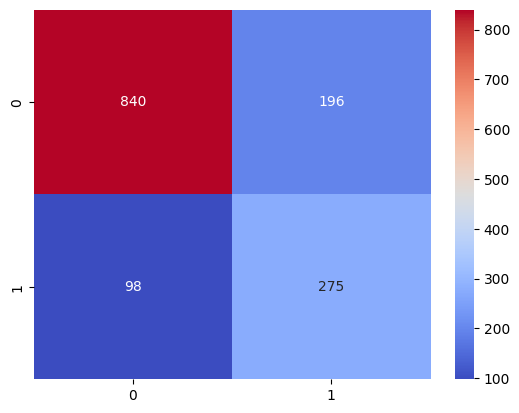

In [109]:
matrix = confusion_matrix(y_test, y_pred)

sns.heatmap(matrix, annot=True, fmt= 'd', cmap='coolwarm')
plt.show()

In [118]:
# saving all the important things in pkl

print(joblib.dump(model, 'model.pkl'))
print(joblib.dump(encoder, 'encoder.pkl'))
print(joblib.dump(x.columns, 'features.pkl'))

['model.pkl']
['encoder.pkl']
['features.pkl']
